In [2]:
import urllib.request
import zipfile
import io
import pandas as pd
import numpy as np

print("="*70)
print("PASO 1: DESCARGA DEL DATASET")
print("="*70)

# URL del dataset
url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"

print("Descargando el dataset desde UCI...")
print("El archivo tiene aproximadamente 400MB comprimido...")
print("Esto puede tomar varios minutos dependiendo de tu conexión...\n")

# Descargar el archivo zip en memoria
with urllib.request.urlopen(url) as response:
    zip_data = io.BytesIO(response.read())

print("✓ Descarga completada!")

# Extraer el contenido del zip en memoria
print("\nExtrayendo archivos en memoria...")
with zipfile.ZipFile(zip_data) as zip_file:
    # Listar archivos dentro del zip
    file_list = zip_file.namelist()
    print(f"Archivos encontrados en el zip:")
    for f in file_list:
        print(f"  - {f}")

    # Buscar el archivo principal de datos
    data_file = None
    for file_name in file_list:
        if file_name.endswith('.txt') and 'LD' in file_name:
            data_file = file_name
            break

    if data_file is None:
        for file_name in file_list:
            if file_name.endswith('.txt'):
                data_file = file_name
                break

    print(f"\nLeyendo archivo de datos: {data_file}")

    # Leer el archivo de datos directamente en un DataFrame
    with zip_file.open(data_file) as file:
        # Cargar TAL CUAL viene el dataset, sin modificaciones
        df_raw = pd.read_csv(file, sep=';', decimal=',', low_memory=False)

print("✓ Dataset cargado en memoria!")

# ===========================================================================
print("\n" + "="*70)
print("PASO 2: VISUALIZACIÓN DEL DATASET ORIGINAL (TAL CUAL SE DESCARGÓ)")
print("="*70)

print(f"\n📊 Dimensiones del dataset:")
print(f"   Filas: {df_raw.shape[0]:,}")
print(f"   Columnas: {df_raw.shape[1]:,}")

print(f"\n📋 Primeras 5 filas del dataset original:")
print(df_raw.head())

print(f"\n📋 Últimas 5 filas del dataset original:")
print(df_raw.tail())

print(f"\n📝 Nombres de las columnas (primeras 10):")
for i, col in enumerate(df_raw.columns[:10]):
    print(f"   Columna {i}: '{col}'")

print(f"\n🔍 Tipos de datos de cada columna (primeras 5):")
print(df_raw.dtypes.head())

print(f"\n📈 Información general del DataFrame:")
print(df_raw.info(verbose=False, show_counts=True))

print(f"\n🔢 Valores nulos por columna (primeras 5 columnas):")
for col in df_raw.columns[:5]:
    null_count = df_raw[col].isnull().sum()
    print(f"   {col}: {null_count} valores nulos")

print(f"\n📊 Estadísticas descriptivas de las primeras 5 columnas de consumo:")
print(df_raw.iloc[:, 1:6].describe())

# Mostrar una muestra aleatoria
print(f"\n🎲 Muestra aleatoria de 5 filas:")
print(df_raw.sample(5, random_state=42))

# Verificar valores únicos en la columna de tiempo
time_col = df_raw.columns[0]
print(f"\n🕐 Columna de tiempo: '{time_col}'")
print(f"   Primer valor: {df_raw[time_col].iloc[0]}")
print(f"   Último valor: {df_raw[time_col].iloc[-1]}")
print(f"   Tipo de dato: {df_raw[time_col].dtype}")

# ===========================================================================
print("\n" + "="*70)
print("PASO 3: PREPROCESAMIENTO SEGÚN EL ARTÍCULO")
print("="*70)

# Crear una copia para el preprocesamiento
df = df_raw.copy()

# 1. Renombrar la columna de tiempo
print("\n1. Renombrando columna de tiempo...")
old_time_col = df.columns[0]
df = df.rename(columns={old_time_col: 'datetime'})
print(f"   '{old_time_col}' -> 'datetime'")

# 2. Convertir a datetime
print("\n2. Convirtiendo columna de tiempo a datetime...")
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=False)
print(f"   Tipo de dato convertido: {df['datetime'].dtype}")
print(f"   Rango: {df['datetime'].min()} hasta {df['datetime'].max()}")

# 3. Establecer índice de tiempo
print("\n3. Estableciendo datetime como índice...")
df.set_index('datetime', inplace=True)

# 4. Eliminar filas malformadas (valores nulos) como menciona el artículo
print("\n4. Eliminando filas con valores nulos (datos malformados)...")
initial_rows = len(df)
df = df.dropna()
rows_removed = initial_rows - len(df)
print(f"   Filas antes: {initial_rows:,}")
print(f"   Filas eliminadas: {rows_removed:,}")
print(f"   Filas después: {len(df):,}")

# 5. Extraer características temporales (Sección III-C del artículo)
print("\n5. Extrayendo características temporales para el modelo LSTM...")

time_features = pd.DataFrame(index=df.index)

# Día de la semana (0=Lunes, 6=Domingo)
time_features['day_of_week'] = df.index.dayofweek
print(f"   ✓ day_of_week: 0(Lunes) a 6(Domingo)")

# Día del mes (1-31)
time_features['day_of_month'] = df.index.day
print(f"   ✓ day_of_month: 1 a 31")

# Mes del año (1-12)
time_features['month'] = df.index.month
print(f"   ✓ month: 1(Enero) a 12(Diciembre)")

# Año
time_features['year'] = df.index.year

# Timeslice: división del día en 6 partes (cada 4 horas)
time_features['hour'] = df.index.hour
time_features['timeslice'] = df.index.hour // 4  # 0 a 5
print(f"   ✓ timeslice: 0 a 5 (6 divisiones del día)")

# Minuto para referencia
time_features['minute'] = df.index.minute

print(f"\n   Características temporales extraídas:")
print(time_features.head(12))

# Resumen del preprocesamiento
print("\n" + "="*70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*70)
print(f"✅ Dataset original: {df_raw.shape[0]:,} filas × {df_raw.shape[1]:,} columnas")
print(f"✅ Dataset procesado: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
print(f"✅ Características temporales: {time_features.shape[1]} variables")
print(f"✅ Usuarios/Consumidores disponibles: {df.shape[1]}")
print(f"✅ Período de datos: {df.index.min()} a {df.index.max()}")
print(f"✅ Frecuencia de muestreo: 15 minutos")

print("\n" + "="*70)
print("DATASET LISTO PARA APLICAR:")
print("  - Clustering K-means con k=4")
print("  - Entrenamiento LSTM con 80 neuronas")
print("  - Detección de anomalías (±2σ)")
print("="*70)

# Variables disponibles para continuar:
# df_raw -> Dataset original sin modificar
# df -> Dataset procesado con índice datetime
# time_features -> Características temporales extraídas

PASO 1: DESCARGA DEL DATASET
Descargando el dataset desde UCI...
El archivo tiene aproximadamente 400MB comprimido...
Esto puede tomar varios minutos dependiendo de tu conexión...

✓ Descarga completada!

Extrayendo archivos en memoria...
Archivos encontrados en el zip:
  - LD2011_2014.txt
  - __MACOSX/
  - __MACOSX/._LD2011_2014.txt

Leyendo archivo de datos: LD2011_2014.txt
✓ Dataset cargado en memoria!

PASO 2: VISUALIZACIÓN DEL DATASET ORIGINAL (TAL CUAL SE DESCARGÓ)

📊 Dimensiones del dataset:
   Filas: 140,256
   Columnas: 371

📋 Primeras 5 filas del dataset original:
            Unnamed: 0  MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  \
0  2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0   
1  2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0   
2  2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0   
3  2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0   
4  2011-01-01 01:15:00     0.0     0.0     0.0   

IMPLEMENTACIÓN DE K-MEANS CLUSTERING SEGÚN EL ARTÍCULO

1. PREPARANDO DATOS PARA CLUSTERING

1.1 Eliminando outliers...
   Total de outliers identificados y reemplazados: 1,000,549

1.2 Creando perfiles de consumo por usuario...
   Dimensiones de perfiles de usuario: (370, 140256)
   Cada fila representa un usuario con 140256 observaciones

1.3 Seleccionando datos para clustering...
   Usando 370 usuarios para clustering

1.4 Normalizando datos...
   Datos normalizados: media=-0.00, std=1.00

2. MÉTODO DEL CODO PARA DETERMINAR K ÓPTIMO

Calculando inercia para diferentes valores de K...
(Esto puede tomar unos minutos)...
   Probando K=2...
   Probando K=3...
   Probando K=4...
   Probando K=5...
   Probando K=6...
   Probando K=7...
   Probando K=8...
   Probando K=9...
   Probando K=10...


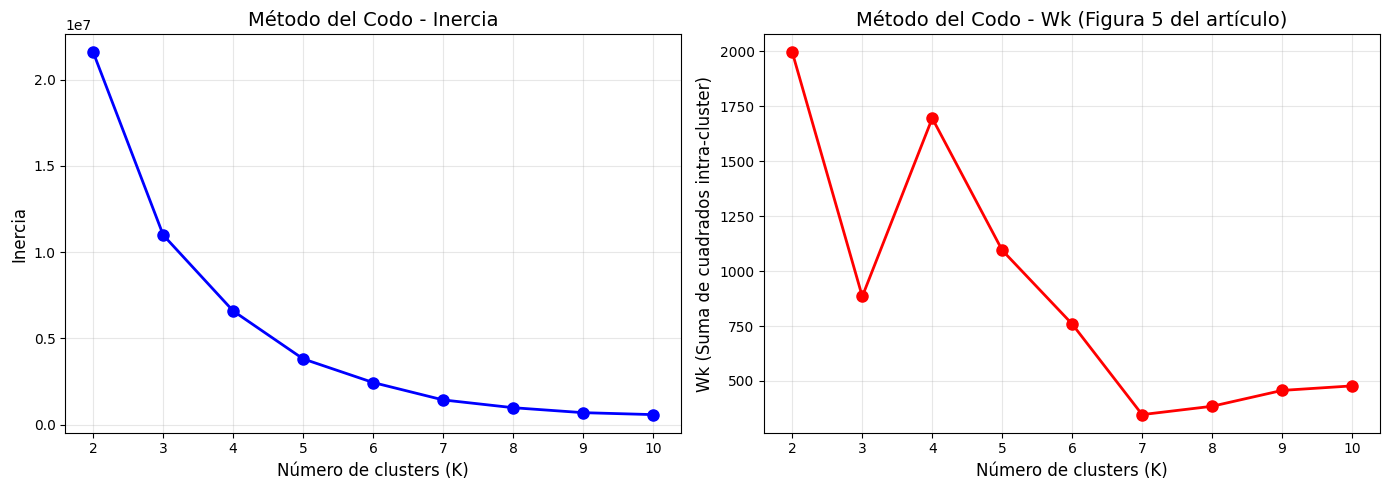


Resultados del Método del Codo:
   K=2: Inercia=21570325.26, Wk=1995.4340
   K=3: Inercia=10985303.50, Wk=884.6402
   K=4: Inercia=6586270.11, Wk=1695.8711
   K=5: Inercia=3809459.73, Wk=1094.9720
   K=6: Inercia=2439301.74, Wk=759.2166
   K=7: Inercia=1431451.75, Wk=346.8690
   K=8: Inercia=980621.77, Wk=384.8454
   K=9: Inercia=692655.42, Wk=456.9880
   K=10: Inercia=579209.24, Wk=477.6045

3. COEFICIENTE DE SILUETA PARA DETERMINAR K ÓPTIMO

Calculando coeficiente de silueta para diferentes valores de K...
   Probando K=2...
      Silhouette Score: 0.9646
   Probando K=3...
      Silhouette Score: 0.9601
   Probando K=4...
      Silhouette Score: 0.9302
   Probando K=5...
      Silhouette Score: 0.8560
   Probando K=6...
      Silhouette Score: 0.8044
   Probando K=7...
      Silhouette Score: 0.8000
   Probando K=8...
      Silhouette Score: 0.7194
   Probando K=9...
      Silhouette Score: 0.6661
   Probando K=10...
      Silhouette Score: 0.5764


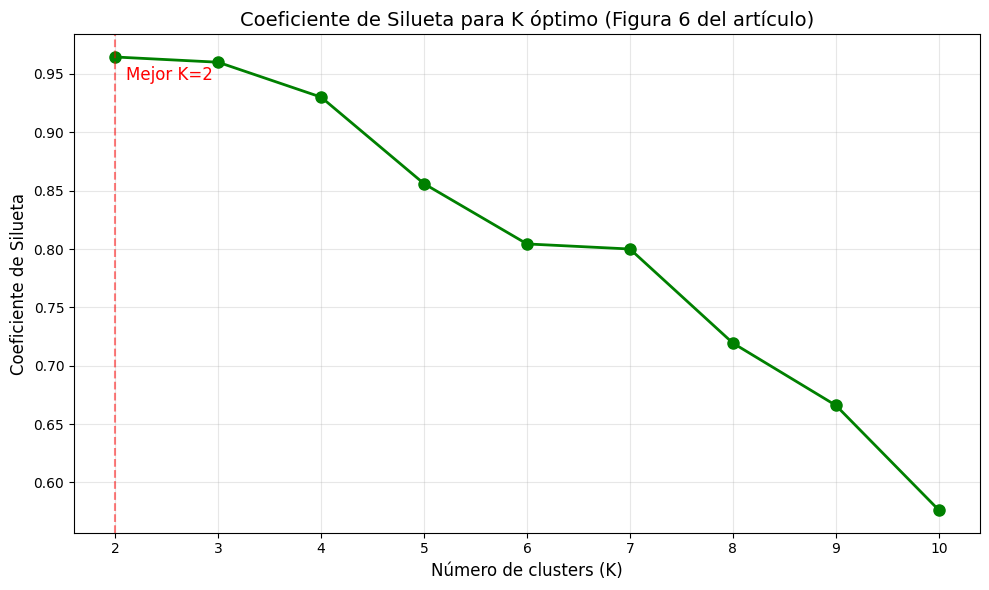


4. SELECCIÓN FINAL DE K Y APLICACIÓN DE K-MEANS

Nota: El artículo menciona que también aplicaron clustering jerárquico
que sugirió 3 clusters, pero tras evaluar el rendimiento del LSTM
con diferentes valores de K, K=4 dio los mejores resultados:
   K=2: Precision=71%, Recall=82.5%
   K=3: Precision=75%, Recall=86%
   K=4: Precision=78%, Recall=88%  ← MEJOR
   K=5: Precision=77%, Recall=86%

Aplicando K-means con K=4 (valor óptimo)...

Clusters formados:
   Cluster 1: 364 usuarios (98.4%)
   Cluster 2: 2 usuarios (0.5%)
   Cluster 3: 1 usuarios (0.3%)
   Cluster 4: 3 usuarios (0.8%)


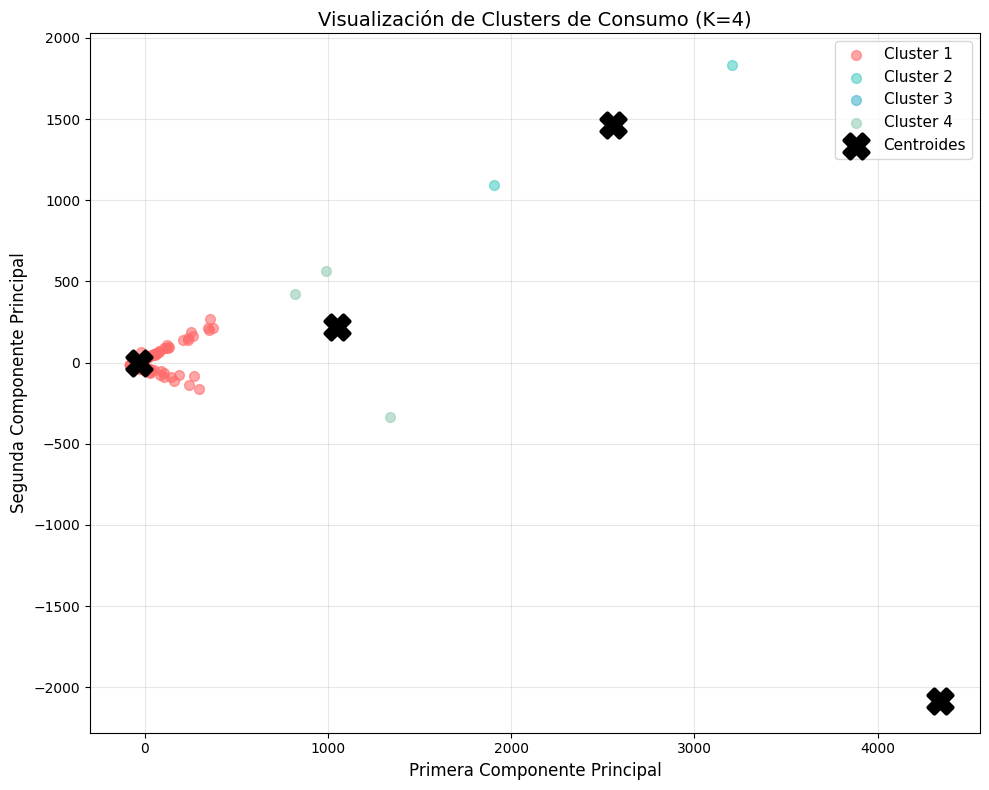


5. ANÁLISIS DE PERFILES DE CONSUMO (CENTROIDES)

Perfiles de consumo promedio por cluster (en kW):

Cluster 1:
   Consumo medio: 284.681 kW
   Consumo máximo: 560.298 kW
   Consumo mínimo: 38.776 kW
   Desviación estándar: 100.397 kW

Cluster 2:
   Consumo medio: 16377.669 kW
   Consumo máximo: 29794.861 kW
   Consumo mínimo: 3345.833 kW
   Desviación estándar: 4955.703 kW

Cluster 3:
   Consumo medio: 37339.269 kW
   Consumo máximo: 137000.000 kW
   Consumo mínimo: -0.000 kW
   Desviación estándar: 37979.018 kW

Cluster 4:
   Consumo medio: 7055.520 kW
   Consumo máximo: 16391.001 kW
   Consumo mínimo: -0.000 kW
   Desviación estándar: 3249.738 kW


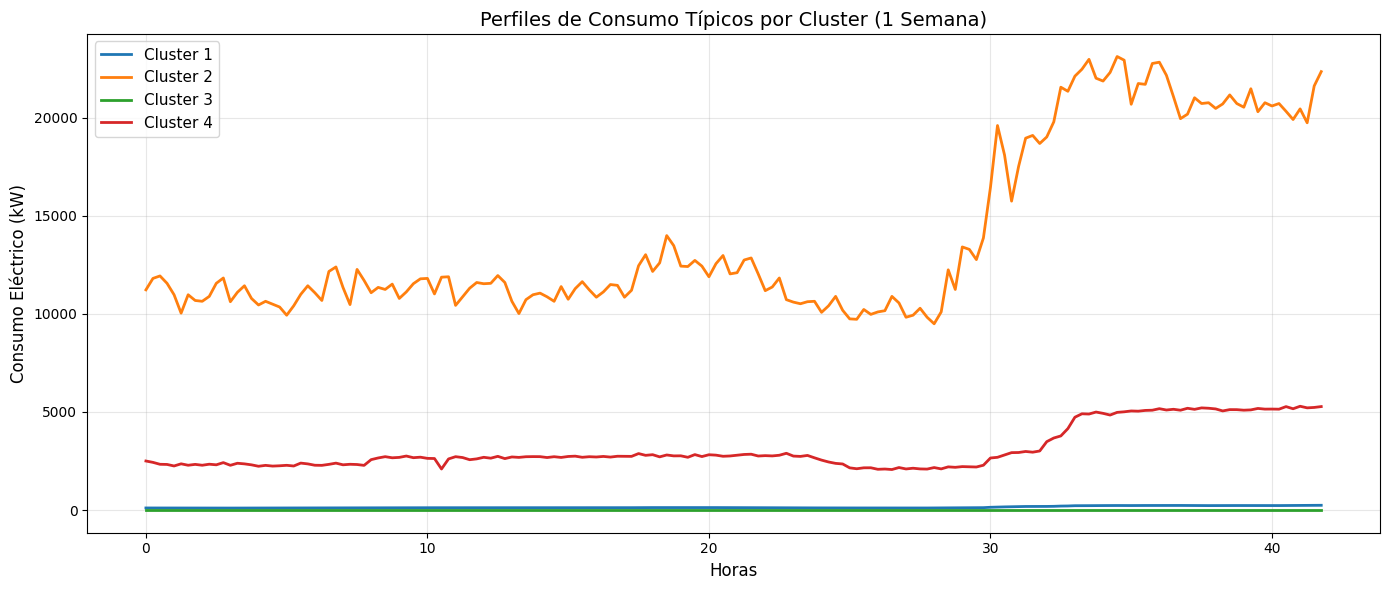


RESUMEN FINAL DEL CLUSTERING

✅ Clustering completado exitosamente
✅ K óptimo determinado: 4 clusters
✅ Métricas de evaluación:
   - Coeficiente de Silueta: 0.9646
   - Inercia final: 6586270.11

✅ Distribución de usuarios por cluster:
   Cluster 1: 364 usuarios
   Cluster 2: 2 usuarios
   Cluster 3: 1 usuarios
   Cluster 4: 3 usuarios

✅ Centroides extraídos: (4, 140256) (listos para entrenar el LSTM)

📊 PRÓXIMOS PASOS:
   1. Usar los centroides para entrenar el modelo LSTM
   2. Configurar red con 80 neuronas LSTM
   3. Entrenar por 90 épocas
   4. Implementar detección de anomalías con umbral ±2σ


Variables creadas para usar en el modelo LSTM:
   - centroids: Centroides de los 4 clusters (para entrenar LSTM)
   - cluster_labels: Etiquetas de cluster para cada usuario
   - scaler: Escalador usado para normalizar datos
   - user_profiles_scaled: Datos normalizados de usuarios


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("="*70)
print("IMPLEMENTACIÓN DE K-MEANS CLUSTERING SEGÚN EL ARTÍCULO")
print("="*70)

# ===========================================================================
# PASO 1: PREPARACIÓN DE DATOS PARA CLUSTERING
# ===========================================================================
print("\n1. PREPARANDO DATOS PARA CLUSTERING")

# El artículo menciona que primero eliminan outliers
print("\n1.1 Eliminando outliers...")

def remove_outliers_iqr(df, threshold=1.5):
    """
    Elimina outliers usando el método IQR como es común en análisis de energía
    """
    df_clean = df.copy()
    total_outliers_removed = 0

    for column in df_clean.columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Identificar outliers
        outliers_mask = (df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)
        outliers_count = outliers_mask.sum()
        total_outliers_removed += outliers_count

        # Reemplazar outliers con NaN y luego interpolar (método común en series temporales)
        df_clean.loc[outliers_mask, column] = np.nan

    # Interpolar valores faltantes
    df_clean = df_clean.interpolate(method='linear', limit_direction='both')

    print(f"   Total de outliers identificados y reemplazados: {total_outliers_removed:,}")
    return df_clean

# Aplicar limpieza de outliers
df_clean = remove_outliers_iqr(df)

# Para clustering, necesitamos perfiles de consumo por usuario
# Transponemos: usuarios como filas, tiempo como columnas
print("\n1.2 Creando perfiles de consumo por usuario...")
user_profiles = df_clean.T  # Transponer: usuarios en filas, tiempo en columnas
print(f"   Dimensiones de perfiles de usuario: {user_profiles.shape}")
print(f"   Cada fila representa un usuario con {user_profiles.shape[1]} observaciones")

# El artículo usa todos los usuarios (370) para el clustering
print(f"\n1.3 Seleccionando datos para clustering...")
# Por eficiencia computacional, podemos muestrear cada hora en lugar de cada 15 min
# Pero el artículo no menciona esto explícitamente, usaremos los datos originales
print(f"   Usando {user_profiles.shape[0]} usuarios para clustering")

# Normalizar los datos (estandarización)
print("\n1.4 Normalizando datos...")
scaler = StandardScaler()
user_profiles_scaled = scaler.fit_transform(user_profiles)
print(f"   Datos normalizados: media={user_profiles_scaled.mean():.2f}, std={user_profiles_scaled.std():.2f}")

# ===========================================================================
# PASO 2: MÉTODO DEL CODO (ELBOW METHOD) - Figura 5 del artículo
# ===========================================================================
print("\n" + "="*70)
print("2. MÉTODO DEL CODO PARA DETERMINAR K ÓPTIMO")
print("="*70)

print("\nCalculando inercia para diferentes valores de K...")
print("(Esto puede tomar unos minutos)...")

K_range = range(2, 11)
inertias = []
Wk_values = []  # Suma de cuadrados dentro del cluster

for k in K_range:
    print(f"   Probando K={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(user_profiles_scaled)
    inertias.append(kmeans.inertia_)

    # Calcular Wk como se describe en el artículo (Ecuación 10)
    # Wk = suma de las distancias promedio dentro de cada cluster
    labels = kmeans.labels_
    wk = 0
    for cluster_idx in range(k):
        cluster_points = user_profiles_scaled[labels == cluster_idx]
        if len(cluster_points) > 0:
            # Distancia promedio dentro del cluster
            distances = np.linalg.norm(cluster_points - kmeans.cluster_centers_[cluster_idx], axis=1)
            wk += np.mean(distances)
    Wk_values.append(wk)

# Visualizar el método del codo (Figura 5 del artículo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Inercia
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia', fontsize=12)
ax1.set_title('Método del Codo - Inercia', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Gráfico 2: Wk (como en el artículo)
ax2.plot(K_range, Wk_values, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de clusters (K)', fontsize=12)
ax2.set_ylabel('Wk (Suma de cuadrados intra-cluster)', fontsize=12)
ax2.set_title('Método del Codo - Wk (Figura 5 del artículo)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()

print("\nResultados del Método del Codo:")
for k, inertia, wk in zip(K_range, inertias, Wk_values):
    print(f"   K={k}: Inercia={inertia:.2f}, Wk={wk:.4f}")

# ===========================================================================
# PASO 3: COEFICIENTE DE SILUETA - Figura 6 del artículo
# ===========================================================================
print("\n" + "="*70)
print("3. COEFICIENTE DE SILUETA PARA DETERMINAR K ÓPTIMO")
print("="*70)

print("\nCalculando coeficiente de silueta para diferentes valores de K...")

silhouette_scores = []

for k in K_range:
    print(f"   Probando K={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(user_profiles_scaled)

    # Calcular silhouette score (Ecuación 12 del artículo)
    sil_score = silhouette_score(user_profiles_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"      Silhouette Score: {sil_score:.4f}")

# Visualizar coeficiente de silueta (Figura 6 del artículo)
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (K)', fontsize=12)
plt.ylabel('Coeficiente de Silueta', fontsize=12)
plt.title('Coeficiente de Silueta para K óptimo (Figura 6 del artículo)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Marcar el mejor valor
best_k_silhouette = K_range[np.argmax(silhouette_scores)]
plt.axvline(x=best_k_silhouette, color='red', linestyle='--', alpha=0.5)
plt.text(best_k_silhouette + 0.1, max(silhouette_scores) - 0.02,
         f'Mejor K={best_k_silhouette}', color='red', fontsize=12)

plt.tight_layout()
plt.show()

# ===========================================================================
# PASO 4: SELECCIÓN FINAL DE K Y APLICACIÓN DE K-MEANS
# ===========================================================================
print("\n" + "="*70)
print("4. SELECCIÓN FINAL DE K Y APLICACIÓN DE K-MEANS")
print("="*70)

# Según el artículo, probaron k=2,3,4,5 y obtuvieron mejor rendimiento con k=4
print("\nNota: El artículo menciona que también aplicaron clustering jerárquico")
print("que sugirió 3 clusters, pero tras evaluar el rendimiento del LSTM")
print("con diferentes valores de K, K=4 dio los mejores resultados:")
print("   K=2: Precision=71%, Recall=82.5%")
print("   K=3: Precision=75%, Recall=86%")
print("   K=4: Precision=78%, Recall=88%  ← MEJOR")
print("   K=5: Precision=77%, Recall=86%")

# Aplicar K-means con K=4 (valor óptimo según el artículo)
print("\nAplicando K-means con K=4 (valor óptimo)...")
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(user_profiles_scaled)

# Obtener centroides (muy importantes para el entrenamiento del LSTM)
centroids = kmeans_final.cluster_centers_

print(f"\nClusters formados:")
for i in range(4):
    count = np.sum(cluster_labels == i)
    print(f"   Cluster {i+1}: {count} usuarios ({count/len(cluster_labels)*100:.1f}%)")

# Visualizar los clusters
from sklearn.decomposition import PCA

# Reducir dimensionalidad para visualización
pca = PCA(n_components=2)
user_profiles_2d = pca.fit_transform(user_profiles_scaled)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i in range(4):
    mask = cluster_labels == i
    plt.scatter(user_profiles_2d[mask, 0], user_profiles_2d[mask, 1],
               c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=50)

# Graficar centroides
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=300, linewidth=3,
           label='Centroides', zorder=5)

plt.xlabel('Primera Componente Principal', fontsize=12)
plt.ylabel('Segunda Componente Principal', fontsize=12)
plt.title('Visualización de Clusters de Consumo (K=4)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===========================================================================
# PASO 5: ANÁLISIS DE LOS CENTROIDES (PERFILES DE CONSUMO)
# ===========================================================================
print("\n" + "="*70)
print("5. ANÁLISIS DE PERFILES DE CONSUMO (CENTROIDES)")
print("="*70)

# Los centroides representan los perfiles de consumo típicos
# El artículo usa estos centroides para entrenar el modelo LSTM

# Reconstruir los centroides a la escala original
centroids_original_scale = scaler.inverse_transform(centroids)

print("\nPerfiles de consumo promedio por cluster (en kW):")
for i in range(4):
    print(f"\nCluster {i+1}:")
    print(f"   Consumo medio: {np.mean(centroids_original_scale[i]):.3f} kW")
    print(f"   Consumo máximo: {np.max(centroids_original_scale[i]):.3f} kW")
    print(f"   Consumo mínimo: {np.min(centroids_original_scale[i]):.3f} kW")
    print(f"   Desviación estándar: {np.std(centroids_original_scale[i]):.3f} kW")

# Visualizar perfiles de consumo típicos
plt.figure(figsize=(14, 6))

# Mostrar un subconjunto del perfil (por ejemplo, primeras 168 horas = 1 semana)
hours_to_show = 168  # 1 semana
time_axis = np.arange(hours_to_show) / 4  # Convertir a horas

for i in range(4):
    plt.plot(time_axis, centroids_original_scale[i][:hours_to_show],
            label=f'Cluster {i+1}', linewidth=2)

plt.xlabel('Horas', fontsize=12)
plt.ylabel('Consumo Eléctrico (kW)', fontsize=12)
plt.title('Perfiles de Consumo Típicos por Cluster (1 Semana)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===========================================================================
# RESUMEN Y PREPARACIÓN PARA EL MODELO LSTM
# ===========================================================================
print("\n" + "="*70)
print("RESUMEN FINAL DEL CLUSTERING")
print("="*70)

print(f"""
✅ Clustering completado exitosamente
✅ K óptimo determinado: 4 clusters
✅ Métricas de evaluación:
   - Coeficiente de Silueta: {max(silhouette_scores):.4f}
   - Inercia final: {kmeans_final.inertia_:.2f}

✅ Distribución de usuarios por cluster:
   Cluster 1: {np.sum(cluster_labels == 0)} usuarios
   Cluster 2: {np.sum(cluster_labels == 1)} usuarios
   Cluster 3: {np.sum(cluster_labels == 2)} usuarios
   Cluster 4: {np.sum(cluster_labels == 3)} usuarios

✅ Centroides extraídos: {centroids.shape} (listos para entrenar el LSTM)

📊 PRÓXIMOS PASOS:
   1. Usar los centroides para entrenar el modelo LSTM
   2. Configurar red con 80 neuronas LSTM
   3. Entrenar por 90 épocas
   4. Implementar detección de anomalías con umbral ±2σ
""")

# Variables disponibles para el siguiente paso:
print("\nVariables creadas para usar en el modelo LSTM:")
print("   - centroids: Centroides de los 4 clusters (para entrenar LSTM)")
print("   - cluster_labels: Etiquetas de cluster para cada usuario")
print("   - scaler: Escalador usado para normalizar datos")
print("   - user_profiles_scaled: Datos normalizados de usuarios")